In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import cv2
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchsummary import summary

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device)
device

device(type='cuda')

In [3]:
!nvidia-smi

Thu Apr  2 17:43:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   51C    P8             16W /   94W |     980MiB /   6144MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Affine là áp dụng phương thức chuẩn hóa nhân với gamma và cộng thêm beta

In [4]:
# phương thức allclose của torch dùng để so sánh 2 tensor để xem chúng có bằng nhau không được cho phép 1 khoảng cách nhất định (không nên so sánh dùng phép so sánh bằng vì dấu phẩy động khó có thể hoàn hảo)
a = torch.tensor([1,2,3,4], dtype = torch.float32)
b = torch.tensor([1,2,3,4.0000001])
torch.allclose(a,b)

True

In [5]:
# hàm so sánh 2 batch norm
def compare_bn(bn1, bn2):
    err = False
    if not torch.allclose(bn1.running_mean, bn2.running_mean):
        print('running mean diff')
        err = True
    if not torch.allclose(bn1.running_var, bn2.running_var):
        print('running var diff')
        err = True
    if bn1.affine and bn2.affine: # kiểm tra xem 2 bn có sử dụng affine hay không ( sử dụng thêm gamma và beta ) 
        if not torch.allclose(bn1.weight, bn2.weight):
            print('weight diff')
            err = True
        if not torch.allclose(bn1.bias, bn2.bias):
            print('bias diff')
            err = True
    if not err:
        print('All params are equals')

In [6]:
class MyBatchNorm2d(nn.BatchNorm2d): # 4 chiều
    def __init__(self, num_features, eps = 1e-5, momentum = 0.1, affine = True, track_running_stats = True):
        super(MyBatchNorm2d, self).__init__(num_features, eps, momentum, affine, track_running_stats)
    # eps là số thực nhỏ được cộng thêm vào mẫu để chuẩn hóa trong bước lấy x - mean / sqrt(var + eps)
    # track_running_stats được dùng để quyết định xem có ghi nhớ lại mean và var trong quá trình huần luyện không, nếu không lúc test sẽ dùng trực tiếp mean và var của dữ liệu vào
    # momentum quyết định xem bao nhiêu phần dữ liệu cũ và bao nhiêu phần dữ liệu mới được đóng góp vào mean và var hiện tại 
    def forward(self, X):
        self._check_input_dim(X) # kiểm tra xem đầu vào có phù hợp với loại batchnorm đang dùng không
        exponential_average_factor = 0.0
        if self.training and self.track_running_stats:
            if self.num_batches_tracked is not None:
                self.num_batches_tracked += 1
                if self.momentum is None:
                    exponential_average_factor = 1.0 / float(self.num_batches_tracked)
                else:
                    exponential_average_factor = self.momentum
        if self.training:
            mean = X.mean([0,2,3]) # x có dạng batch, c, h, w batch norm tính mean var theo các chiều trừ c
            var = X.var([0,2,3], unbiased = False) # nếu unbiased là true thì công thức tính var sẽ có mẫu số là n-1 thay vì n
            n = X.numel()/X.size(1) # tính số lượng phần tử của mỗi kênh, mẫu là số lượng của chiều với chỉ số 1 chính là channel
            with torch.no_grad():
                self.running_mean = exponential_average_factor * mean + (1-exponential_average_factor) * self.running_mean 
                self.running_var = exponential_average_factor * var * n / (n-1) + (1-exponential_average_factor) * self.running_var
                # khi tính var cho training batch hiện tại thì tính var theo công thức chuẩn
                # còn khi tính var tích lũy thì sử dụng ước lượng không chệch nhân n sau đó chia cho n-1
        else:
            mean = self.running_mean
            var = self.running_var

        # chuẩn hóa input
        mean_reshape = mean.reshape(1,-1,1,1)
        var_reshape = var.reshape(1,-1,1,1)
        X = (X - mean_reshape)/torch.sqrt(var_reshape + self.eps)

        # biến đổi affine
        if self.affine:
            weight = self.weight.reshape(1,-1,1,1) 
            bias = self.bias.reshape(1,-1,1,1)
            X = X * weight + bias
        return X 

In [7]:
my_bn = MyBatchNorm2d(3, affine = True)
bn = nn.BatchNorm2d(3, affine = True)
compare_bn(my_bn, bn)

All params are equals


In [8]:
my_bn.state_dict()

OrderedDict([('weight', tensor([1., 1., 1.])),
             ('bias', tensor([0., 0., 0.])),
             ('running_mean', tensor([0., 0., 0.])),
             ('running_var', tensor([1., 1., 1.])),
             ('num_batches_tracked', tensor(0))])

In [9]:
bn.state_dict()

OrderedDict([('weight', tensor([1., 1., 1.])),
             ('bias', tensor([0., 0., 0.])),
             ('running_mean', tensor([0., 0., 0.])),
             ('running_var', tensor([1., 1., 1.])),
             ('num_batches_tracked', tensor(0))])

In [10]:
my_bn.load_state_dict(bn.state_dict())

<All keys matched successfully>

In [11]:
compare_bn(my_bn, bn)

All params are equals


In [12]:
# run train
my_bn.train()
bn.train()
for i in range(10):
    scale = torch.randint(1, 10, (1, 3, 1, 1)).float()
    bias = torch.randint(-10, 10, (1, 3, 1, 1)).float()
    X = torch.randn(10,3,100,100) * scale + bias # vì hàm randn đã được rand theo phân phối chuẩn nên batch norm có thể không cần hoạt động mấy ta biến đổi để đầu vào có mean là bias và std là scale
    out1 = my_bn(X)
    out2 = bn(X)
    compare_bn(my_bn, bn)
    torch.allclose(out1, out2)
    print(f'Max diff = {(out1 - out2).abs().max().item()}')

# run eval
my_bn.eval()
bn.eval()
for i in range(10):
    scale = torch.randint(1, 10, (1, 3, 1, 1)).float()
    bias = torch.randint(-10, 10, (1, 3, 1, 1)).float()
    X = torch.randn(10,3,100,100) * scale + bias # vì hàm randn đã được rand theo phân phối chuẩn nên batch norm có thể không cần hoạt động mấy ta biến đổi để đầu vào có mean là bias và std là scale
    out1 = my_bn(X)
    out2 = bn(X)
    compare_bn(my_bn, bn)
    print(f'Max diff = {(out1 - out2).abs().max().item()}')

All params are equals
Max diff = 4.76837158203125e-07
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 7.152557373046875e-07
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 7.152557373046875e-07
All params are equals
Max diff = 7.152557373046875e-07
All params are equals
Max diff = 4.76837158203125e-07
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 7.152557373046875e-07
All params are equals
Max diff = 1.430511474609375e-06
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 4.76837158203125e-07
All params are equals
Max diff = 1.9073486328125e-06
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 9.5367431640625e-07
All params are equals
Max diff = 

In [13]:
def load_data(data_dir):
    transform = transforms.Compose([
        transforms.ToTensor(), # có tác dụng đổi lại thứ tự các chiều, thường thì định dạng pil để số channel xuống dưới cùng
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    trainset = torchvision.datasets.CIFAR10(root = data_dir, train = True, download = True, transform = transform)
    testset = torchvision.datasets.CIFAR10(root = data_dir, train = False, transform = transform)
    return trainset, testset

In [44]:
# cifar10 3*32*32
class Net(nn.Module):
    def __init__(self, l1 = 120, l2 = 84):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 6, kernel_size = 5)
        # 6*28*28
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        # 6*14*14
        self.conv2 = nn.Conv2d(in_channels = 6, out_channels = 16, kernel_size = 5)
        # 16*10*10, dùng tiếp pool để tạo thành 16*5*5
        self.fc1 = nn.Linear(16*5*5, l1)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, 10)
        self.softmax = nn.Softmax(dim = 1)

    def forward(self, X):
        X = self.conv1(X)
        X = F.relu(X)
        X = self.pool(X)
        X = self.conv2(X)
        X = F.relu(X)
        X = self.pool(X)
        X = X.view(-1, 16*5*5)
        X = self.fc1(X)
        X = F.relu(X)
        X = self.fc2(X)
        X = F.relu(X)
        X = self.fc3(X)
        X = self.softmax(X)
        return X

In [25]:
test_net = Net()
rand_input = torch.randn(4,3,32,32)
test_net(rand_input).shape

c:\Gr1 3.12\Weekly_Hw_GR1\.venv\Lib\site-packages\torch\nn\modules\module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


torch.Size([4, 10])

In [15]:
import os
base_ex_dir = os.path.join(os.getcwd(), 'Ex13') 
os.makedirs(os.path.join(base_ex_dir, 'data'), exist_ok = True )
data_dir = os.path.join(base_ex_dir, 'data')

In [16]:
train_dataset, test_dataset = load_data(data_dir)

c:\Gr1 3.12\Weekly_Hw_GR1\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [17]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 128, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 128, shuffle = True)

In [18]:
epochs = 50
warm_epoch = 5
init_lr = 1e-1 # max lr
last_lr = 1e-5 # min lr
T_max = epochs # thời gian warm up cuối
T_warmup = 5
T_cur = 0
lr_list = [0]

net = Net()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
net.to(torch.device(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = init_lr, momentum = 0.9)

# LR annealing formula:
* Ý tưởng chính là chia ra làm 2 giai đoạn warmup và annealing, warmup sẽ tăng dần dần lr lên đến giá trị maximum của lr, còn annealing sẽ giảm dần về giá trị bé nhất
* Thời điểm warmup cuối là T warmup, các lr trong thời gian này được tính bởi công thức T_cur / T_warmup * max_lr
* Giai đoạn annealing lr được tính theo công thức last_lr + 0.5*(init_lr - last_lr)*(1 + np.cos((T_cur - T_warmup)/(T_max - T_warmup) * np.pi))

In [19]:
# 1 đơn vị thời gian là 1 epoch
for epoch in range(1, epochs + 1):
    net.train()
    running_loss = 0.0
    epoch_steps = 0
    T_cur +=1
    if T_cur <= T_warmup:
        cur_lr = T_cur / T_warmup * init_lr
    else:
        cur_lr = last_lr + 0.5*(init_lr - last_lr)*(1 + np.cos((T_cur - T_warmup)/(T_max - T_warmup) * np.pi))
    lr_list.append(cur_lr)
    for param in optimizer.param_groups:
        param['lr'] = cur_lr # 1 optimzer có thể có nhiều nhóm param có thể là param dành riêng cho các lớp
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = net(inputs)
        loss  = criterion(output, labels)
        loss.backward()
        optimizer.step()

        # print stats
        running_loss += loss.item() # tổng loss của các batch
        epoch_steps += 1
        if i + 1 == len(train_loader): # nếu là batch cuối
            print(f"[Epoch {epoch}] loss: {(running_loss / epoch_steps):.3f}")
print("finish training")

c:\Gr1 3.12\Weekly_Hw_GR1\.venv\Lib\site-packages\torch\nn\modules\module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


[Epoch 1] loss: 2.302
[Epoch 2] loss: 2.223
[Epoch 3] loss: 2.111
[Epoch 4] loss: 2.097
[Epoch 5] loss: 2.277
[Epoch 6] loss: 2.361
[Epoch 7] loss: 2.361
[Epoch 8] loss: 2.361
[Epoch 9] loss: 2.361
[Epoch 10] loss: 2.361
[Epoch 11] loss: 2.361
[Epoch 12] loss: 2.361
[Epoch 13] loss: 2.361
[Epoch 14] loss: 2.361
[Epoch 15] loss: 2.361
[Epoch 16] loss: 2.361
[Epoch 17] loss: 2.361
[Epoch 18] loss: 2.361
[Epoch 19] loss: 2.361
[Epoch 20] loss: 2.361
[Epoch 21] loss: 2.361
[Epoch 22] loss: 2.361
[Epoch 23] loss: 2.361
[Epoch 24] loss: 2.361
[Epoch 25] loss: 2.361
[Epoch 26] loss: 2.361
[Epoch 27] loss: 2.361
[Epoch 28] loss: 2.361
[Epoch 29] loss: 2.361
[Epoch 30] loss: 2.361
[Epoch 31] loss: 2.361
[Epoch 32] loss: 2.361
[Epoch 33] loss: 2.361
[Epoch 34] loss: 2.361
[Epoch 35] loss: 2.361
[Epoch 36] loss: 2.361
[Epoch 37] loss: 2.361
[Epoch 38] loss: 2.361
[Epoch 39] loss: 2.361
[Epoch 40] loss: 2.361
[Epoch 41] loss: 2.361
[Epoch 42] loss: 2.361
[Epoch 43] loss: 2.361
[Epoch 44] loss: 2.3

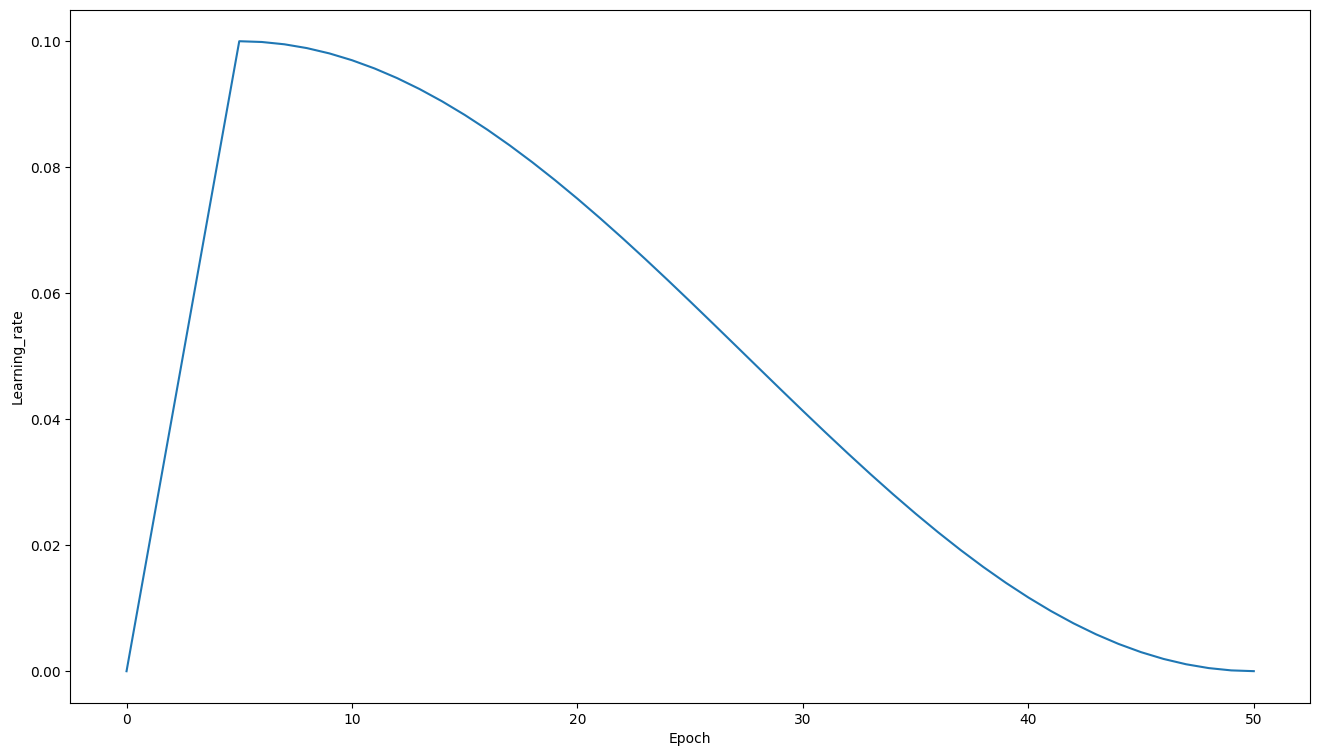

In [20]:
plt.figure(figsize = (16,9))
plt.plot(range(len(lr_list)), lr_list)
plt.xlabel("Epoch")
plt.ylabel("Learning_rate")
plt.show()

In [43]:
from ray.tune import CLIReporter
from ray import tune
from torch.utils.data import random_split
from functools import partial
from ray import train
from ray.train import Checkpoint 
import tempfile
import pickle

In [22]:
! wmic cpu get Name, NumberOfCores, NumberOfLogicalProcessors

Name                                  NumberOfCores  NumberOfLogicalProcessors  

12th Gen Intel(R) Core(TM) i9-12900H  14             20                         





In [47]:
def train_cifar(config, checkpoint_dir = None, data_dir = None):
    net = Net(config['l1'], config['l2'])
    net.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr = config['lr'], momentum = 0.9)
    if checkpoint_dir:
        model_state, optimizer_state = torch.load(f = checkpoint_dir, pickle_module=pickle)
        net.load_state_dict(model_state)
        optimizer.load_state_dict(optimizer_state)
    trainset, testset = load_data(data_dir)
    train_abs = int(len(trainset) * 0.8)
    train_subset, val_subset = random_split(trainset, [train_abs, len(trainset) - train_abs])
    train_loader = torch.utils.data.DataLoader(
        train_subset,
        batch_size = int(config['batch_size']),
        shuffle = True,
        num_workers = 8
    )
    val_loader = torch.utils.data.DataLoader(
        val_subset,
        batch_size = int(config['batch_size']),
        shuffle = True,
        num_workers = 8
    )

    for epoch in range(5):
        net.train()
        running_loss = 0
        epoch_steps = 0
        for i, data in enumerate(train_loader):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            output = net(inputs)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            epoch_steps += 1
            if i % int((len(train_loader) - 1)/2) == 0:
                print(f'[Epoch: {epoch}, batch: {i}] loss: {(running_loss / epoch_steps):.3f}')
                running_loss = 0.0
                epoch_steps = 0

        net.eval()
        val_loss = 0.0
        val_steps = 0
        total = 0
        correct = 0
        for i, data in enumerate(val_loader):
            with torch.no_grad():
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                output = net(inputs)
                total += labels.size(0)
                pred = output.argmax(dim = 1)
                correct += pred.eq(labels.view_as(pred)).sum().item()
                loss = criterion(output, labels)
                val_loss += loss.item()
                val_steps += 1
        with tempfile.TemporaryDirectory() as temp_checkpoint_dir:
            path = os.path.join(temp_checkpoint_dir, "model.pt")
            torch.save(obj = (net.state_dict(), optimizer.state_dict()), f = path, pickle_module=pickle)
            checkpoint = Checkpoint.from_directory(temp_checkpoint_dir)
            tune.report(
                {"loss": (val_loss / val_steps), "accuracy": (correct / total)},
                checkpoint=checkpoint
            )
    print('finish training')

l1 và l2 là số lượng của neuron mỗi lớp, tương ứng với số lượng hàng của các lớp linear

In [48]:
# choice hoạt động tương tự random search, num_samples là số lần bóc thăm mỗi lần bốc chọn ra 1 tổ hơp ngẫu nhiên
def main(num_samples = 10, gpus_per_trial = 1):
        config = {
        "l1": tune.choice([32, 64]),
        "l2": tune.choice([32, 64]),
        "lr": tune.choice([1e-4, 1e-2]),
        "batch_size": 16
        }
        reporter = CLIReporter(
            metric_columns=["loss", "accuracy", "training_iteration"])
        # bảng thông báo hiện ra các cột, danh sách các cột có thể chọn từ những gì ta truyền vào tune.report
        result = tune.run(
                # run dùng để tune và lưu trữ các checkpoint để có thể thuận lợi chọn ra checkpoint tốt nhất
                partial(train_cifar, data_dir=data_dir), # truyền trước data dir cho train cifar, các tham số khác sẽ được tune vào sau đó
                # nếu điển tham số mặc định cho data dir cho train_cifar thì có thể điền trực tiếp tên hàm là train_cifar thay vì partial
                resources_per_trial={"cpu": 8, "gpu": gpus_per_trial},
                config=config,
                num_samples=num_samples,
                progress_reporter=reporter,
                storage_path = os.path.join(os.getcwd(), 'Ex13'),
                name = "checkpoints_cifar10"
                )
main(num_samples=10, gpus_per_trial=1)

2026-04-02 19:06:33,105	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


== Status ==
Current time: 2026-04-02 19:06:33 (running for 00:00:00.18)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/HOANGQ~1/AppData/Local/Temp/ray/session_2026-04-02_17-50-25_422244_33352/artifacts/2026-04-02_19-06-33/checkpoints_cifar10/driver_artifacts
Number of trials: 10/10 (10 PENDING)




(func pid=12500) c:\Gr1 3.12\Weekly_Hw_GR1\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
(func pid=12500)   entry = pickle.load(f, encoding="latin1")


== Status ==
Current time: 2026-04-02 19:06:38 (running for 00:00:05.20)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/HOANGQ~1/AppData/Local/Temp/ray/session_2026-04-02_17-50-25_422244_33352/artifacts/2026-04-02_19-06-33/checkpoints_cifar10/driver_artifacts
Number of trials: 10/10 (9 PENDING, 1 RUNNING)


== Status ==
Current time: 2026-04-02 19:06:43 (running for 00:00:10.27)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/HOANGQ~1/AppData/Local/Temp/ray/session_2026-04-02_17-50-25_422244_33352/artifacts/2026-04-02_19-06-33/checkpoints_cifar10/driver_artifacts
Number of trials: 10/10 (9 PENDING, 1 RUNNING)


== Status ==
Current time: 2026-04-02 19:06:48 (running for 00:00:15.36)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/H

Trial name,accuracy,loss,should_checkpoint
train_cifar_63e03_00000,0.218,2.24289,True
train_cifar_63e03_00001,0.1003,2.30248,True
train_cifar_63e03_00002,0.0991,2.30236,True
train_cifar_63e03_00003,0.1351,2.32601,True
train_cifar_63e03_00004,0.103,2.30274,True
train_cifar_63e03_00005,0.2685,2.192,True
train_cifar_63e03_00006,0.1007,2.30262,True
train_cifar_63e03_00007,0.1663,2.29471,True
train_cifar_63e03_00008,0.1018,2.3025,True
train_cifar_63e03_00009,0.1637,2.29746,True


...

== Status ==
Current time: 2026-04-02 19:52:50 (running for 00:46:16.95)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/HOANGQ~1/AppData/Local/Temp/ray/session_2026-04-02_17-50-25_422244_33352/artifacts/2026-04-02_19-06-33/checkpoints_cifar10/driver_artifacts
Number of trials: 10/10 (1 RUNNING, 9 TERMINATED)


== Status ==
Current time: 2026-04-02 19:52:55 (running for 00:46:22.00)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/HOANGQ~1/AppData/Local/Temp/ray/session_2026-04-02_17-50-25_422244_33352/artifacts/2026-04-02_19-06-33/checkpoints_cifar10/driver_artifacts
Number of trials: 10/10 (1 RUNNING, 9 TERMINATED)


== Status ==
Current time: 2026-04-02 19:53:00 (running for 00:46:27.06)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/U

(func pid=37508) Checkpoint successfully created at: Checkpoint(filesystem=local, path=c:/Gr1 3.12/Weekly_Hw_GR1/Ex13/checkpoints_cifar10/train_cifar_63e03_00009_9_l1=32,l2=64,lr=0.0100_2026-04-02_19-06-33/checkpoint_000003)


== Status ==
Current time: 2026-04-02 19:53:45 (running for 00:47:12.49)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/HOANGQ~1/AppData/Local/Temp/ray/session_2026-04-02_17-50-25_422244_33352/artifacts/2026-04-02_19-06-33/checkpoints_cifar10/driver_artifacts
Number of trials: 10/10 (1 RUNNING, 9 TERMINATED)


== Status ==
Current time: 2026-04-02 19:53:50 (running for 00:47:17.53)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/HOANGQ~1/AppData/Local/Temp/ray/session_2026-04-02_17-50-25_422244_33352/artifacts/2026-04-02_19-06-33/checkpoints_cifar10/driver_artifacts
Number of trials: 10/10 (1 RUNNING, 9 TERMINATED)


== Status ==
Current time: 2026-04-02 19:53:55 (running for 00:47:22.58)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/U

(func pid=37508) Checkpoint successfully created at: Checkpoint(filesystem=local, path=c:/Gr1 3.12/Weekly_Hw_GR1/Ex13/checkpoints_cifar10/train_cifar_63e03_00009_9_l1=32,l2=64,lr=0.0100_2026-04-02_19-06-33/checkpoint_000004)
2026-04-02 19:54:38,182	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'c:/Gr1 3.12/Weekly_Hw_GR1/Ex13/checkpoints_cifar10' in 0.0199s.
2026-04-02 19:54:38,189	INFO tune.py:1041 -- Total run time: 2885.08 seconds (2885.05 seconds for the tuning loop).


== Status ==
Current time: 2026-04-02 19:54:38 (running for 00:48:05.07)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/20 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/HOANGQ~1/AppData/Local/Temp/ray/session_2026-04-02_17-50-25_422244_33352/artifacts/2026-04-02_19-06-33/checkpoints_cifar10/driver_artifacts
Number of trials: 10/10 (10 TERMINATED)
+-------------------------+------------+-----------------+------+------+--------+---------+------------+----------------------+
| Trial name              | status     | loc             |   l1 |   l2 |     lr |    loss |   accuracy |   training_iteration |
|-------------------------+------------+-----------------+------+------+--------+---------+------------+----------------------|
| train_cifar_63e03_00000 | TERMINATED | 127.0.0.1:12500 |   64 |   32 | 0.01   | 2.24289 |     0.218  |                    5 |
| train_cifar_63e03_00001 | TERMINATED | 127.0.0.1:25316 |   32 |   64 | 0.0001 | 2.30248 |     0.100

In [75]:
import numpy as np
from sklearn.datasets import make_classification
from skorch import NeuralNetClassifier
from sklearn.model_selection import GridSearchCV, ShuffleSplit

In [51]:
trainset, testset = load_data(data_dir)

c:\Gr1 3.12\Weekly_Hw_GR1\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [62]:
X, y = np.asarray(trainset.data), np.asarray(trainset.targets)
X.shape

(50000, 32, 32, 3)

In [63]:
X = X.transpose(0,3,1,2)
X = X.astype(np.float32)
y = y.astype(np.int64)

In [64]:
X.shape

(50000, 3, 32, 32)

In [65]:
net = NeuralNetClassifier(
    Net, # nn module
    max_epochs = 5,
    lr = 0.01,
    iterator_train__shuffle = True
)

In [ ]:
net.fit(X, y)
y_proba = net.predict_proba(X)
#  khi fit sẽ tự chia train val

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        2.1207       0.3133        1.9087  2.1174
      2        1.8421       0.3621        1.7928  2.0631
      3        1.6799       0.4349        1.5890  2.0382
      4        1.5838       0.4432        1.5515  2.0541
      5        1.4952       0.4464        1.5426  2.1693


In [72]:
net.get_params()

{'module': __main__.Net,
 'criterion': torch.nn.modules.loss.NLLLoss,
 'optimizer': torch.optim.sgd.SGD,
 'lr': 0.01,
 'max_epochs': 5,
 'batch_size': 128,
 'iterator_train': torch.utils.data.dataloader.DataLoader,
 'iterator_valid': torch.utils.data.dataloader.DataLoader,
 'dataset': skorch.dataset.Dataset,
 'train_split': False,
 'callbacks': None,
 'predict_nonlinearity': 'auto',
 'warm_start': False,
 'verbose': 0,
 'device': 'cpu',
 'compile': False,
 'use_caching': 'auto',
 'torch_load_kwargs': None,
 '_params_to_validate': {'iterator_train__shuffle'},
 'iterator_train__shuffle': True,
 'classes': None,
 'callbacks__epoch_timer': <skorch.callbacks.logging.EpochTimer at 0x2015cb08920>,
 'callbacks__train_loss': <skorch.callbacks.scoring.PassthroughScoring at 0x2015cb0ab70>,
 'callbacks__train_loss__name': 'train_loss',
 'callbacks__train_loss__lower_is_better': True,
 'callbacks__train_loss__on_train': True,
 'callbacks__valid_loss': <skorch.callbacks.scoring.PassthroughScoring at

In [76]:
rs = ShuffleSplit(n_splits = 5, test_size = 0.5, train_size = 0.5, random_state = 36)

In [78]:
net.set_params(train_split = False, verbose = 0)
# vì sử dụng gridsearch đã tự chia train val rồi nên nếu train split tiếp thì làm vơi data
# chú ý n_jobs nếu tham để là -1 thì hoạt động song song với dataset lớn có thê gây tràn ram
dict_param = {
        "module__l1": [32, 64],
        "module__l2": [32, 64],
        "lr": [1e-4, 1e-2],
        "batch_size": [16]
        }
gs = GridSearchCV(estimator = net, cv=rs, param_grid = dict_param, n_jobs=1, scoring='accuracy')
gs.fit(X, y)
print(f'best_score: {gs.best_score_}, best params: {gs.best_params_}')

best_score: 0.410392, best params: {'batch_size': 16, 'lr': 0.01, 'module__l1': 64, 'module__l2': 64}
